# Improved Defect Detection (Crack vs Hole Classification).

(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

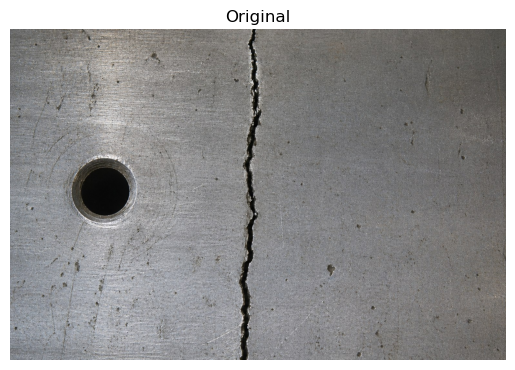

In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("IMAGE 2026-04-29 11:11:15.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

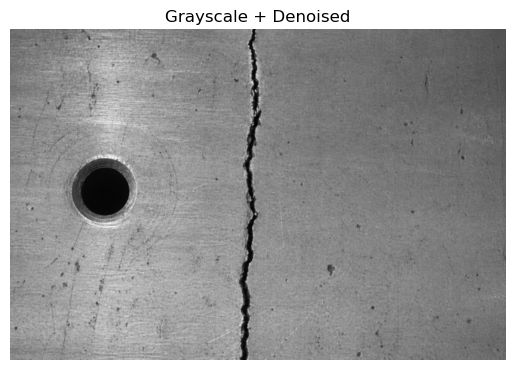

In [2]:

# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Denoise
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(blur, cmap='gray')
plt.title("Grayscale + Denoised")
plt.axis('off')


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

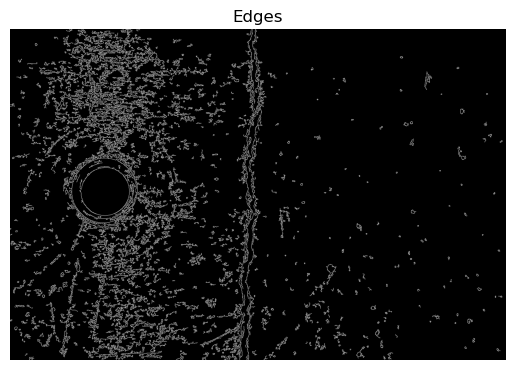

In [3]:

# Edge detection
edges = cv2.Canny(blur, 50, 150)

plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.axis('off')


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

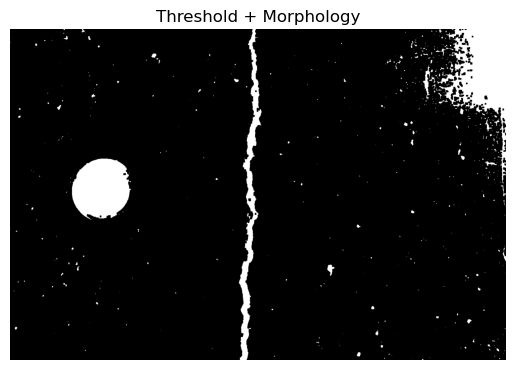

In [4]:

# Threshold
_, thresh = cv2.threshold(blur, 90, 255, cv2.THRESH_BINARY_INV)

# Morphology
kernel = np.ones((3,3), np.uint8)
morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

plt.imshow(morph, cmap='gray')
plt.title("Threshold + Morphology")
plt.axis('off')


(np.float64(-0.5), np.float64(1535.5), np.float64(1023.5), np.float64(-0.5))

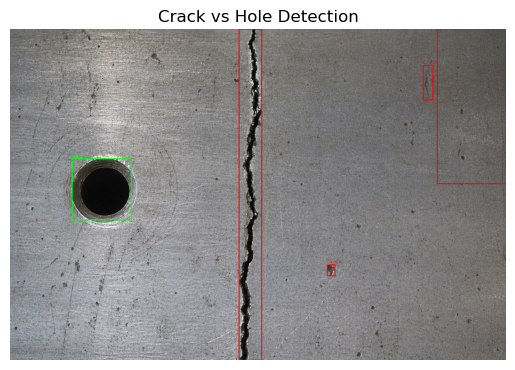

In [5]:

# Find contours
contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result = img_rgb.copy()

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 300:
        continue

    perimeter = cv2.arcLength(cnt, True)
    if perimeter == 0:
        continue

    circularity = 4 * np.pi * (area / (perimeter * perimeter))

    x,y,w,h = cv2.boundingRect(cnt)

    # Classification
    if circularity > 0.6:
        label = "Hole"
        color = (0,255,0)
    else:
        label = "Crack"
        color = (255,0,0)

    cv2.rectangle(result, (x,y), (x+w, y+h), color, 2)
    cv2.putText(result, label, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

plt.imshow(result)
plt.title("Crack vs Hole Detection")
plt.axis('off')
